In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [56]:
data = pd.read_csv('../../datasets/placement2.csv')

In [57]:
data.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'package')

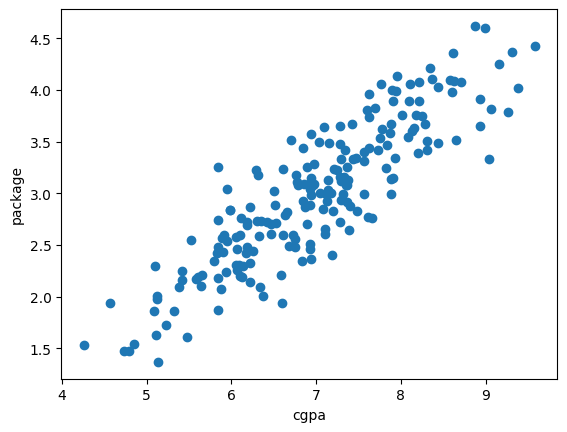

In [5]:
plt.scatter(data['cgpa'],data['package'])
plt.xlabel('cgpa')
plt.ylabel('package')

In [8]:
x = data[['cgpa']]
y = data['package']

In [9]:
x.shape

(200, 1)

In [10]:
y.shape

(200,)

In [58]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [13]:
x_train

,cgpa
169,9.31
97,5.98
31,8.10
12,8.94
35,6.87
...,...
106,6.13
14,7.73
92,7.90
179,7.14


In [14]:
y_train

169    4.37
97     2.84
31     3.89
12     3.65
35     2.87
       ... 
106    2.19
14     3.42
92     4.00
179    3.03
102    1.37
Name: package, Length: 140, dtype: float64

In [15]:
from sklearn.linear_model import LinearRegression

In [16]:
lr = LinearRegression()

In [17]:
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Text(0, 0.5, 'placement')

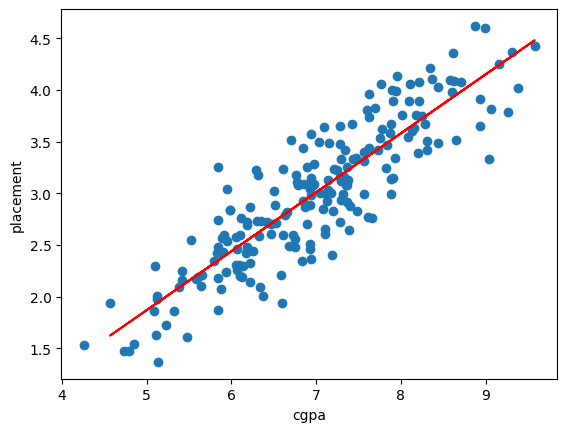

In [18]:
plt.scatter(data['cgpa'],data['package'])
plt.plot(x_train,lr.predict(x_train),color='red')
plt.xlabel('cgpa')
plt.ylabel('placement')

In [20]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [21]:
y_pred = lr.predict(x_test)

In [23]:
y_test.values

array([2.79, 3.23, 3.26, 3.04, 3.34, 4.21, 2.94, 2.87, 2.99, 3.58, 1.63,
       2.08, 4.08, 2.21, 3.47, 3.64, 2.74, 3.08, 2.17, 2.99, 2.31, 2.35,
       3.4 , 3.08, 3.81, 2.19, 1.53, 2.89, 3.16, 2.48, 3.51, 2.98, 3.39,
       3.28, 2.73, 3.74, 2.6 , 3.13, 3.82, 3.15, 3.  , 3.24, 4.36, 2.71,
       2.01, 2.46, 3.49, 2.83, 1.54, 2.77, 1.87, 2.56, 2.99, 2.6 , 2.99,
       4.03, 3.15, 3.83, 2.51, 2.61])

In [24]:
# mean absolute error
print('MAE of data is : ',mean_absolute_error(y_test,y_pred) )

MAE of data is :  0.2606898249919377


In [27]:
# MSE 
print('MAE of data is : ',mean_squared_error(y_test,y_pred))

MAE of data is :  0.09995369482155111


In [28]:
# root mean square error
print('RMSE : ',np.sqrt(mean_squared_error(y_pred,y_test)))

RMSE :  0.3161545426236212


In [30]:
# r2 score
print('MSE',r2_score(y_pred,y_test))
r2 = r2_score(y_pred,y_test)
# Note -> We calculate the r2_score of whole predicted data

MSE 0.6760768945610578


In [31]:
# adjusted r2_score
x_test.shape

(60, 1)

In [32]:
adjusted_r2_score = 1 - ((1-r2)*(60-1))/(60-1-1)

In [33]:
adjusted_r2_score

0.6704920134328002

In [35]:
# adding any random_feature
new_data = data.copy()
new_data['random_feat'] = np.random.random(200)

new_data = new_data[['cgpa','random_feat','package']]
new_data.head()

,cgpa,random_feat,package
0,6.89,0.938956,3.26
1,5.12,0.239438,1.98
2,7.82,0.892226,3.25
3,7.42,0.908873,3.67
4,6.94,0.164064,3.57


Text(0, 0.5, 'random_feat')

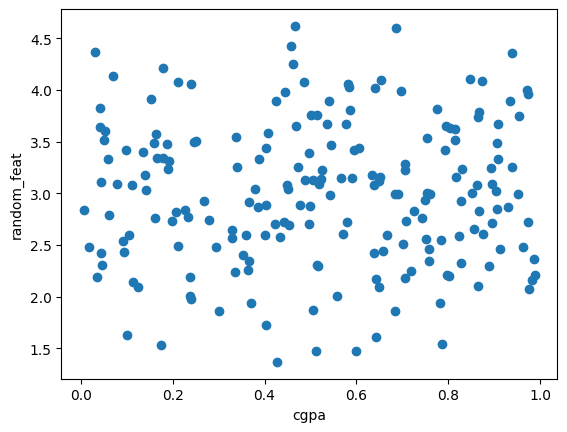

In [37]:
plt.scatter(new_data['random_feat'],new_data['package'])
plt.xlabel('cgpa')
plt.ylabel('random_feat')

In [38]:
x = new_data.iloc[:,0:2]
y = new_data.iloc[:,-1]

In [39]:
x.shape

(200, 2)

In [40]:
x.head()

,cgpa,random_feat
0,6.89,0.938956
1,5.12,0.239438
2,7.82,0.892226
3,7.42,0.908873
4,6.94,0.164064


In [41]:
y.head()

0    3.26
1    1.98
2    3.25
3    3.67
4    3.57
Name: package, dtype: float64

In [42]:
# splitting data
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [43]:
x_train.head()

,cgpa,random_feat
169,9.31,0.031734
97,5.98,0.227065
31,8.10,0.425673
12,8.94,0.794436
35,6.87,0.384948


In [44]:
x_train.shape

(140, 2)

In [45]:
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [46]:
y_pred = lr.predict(x_test)

In [47]:
print('r2 score',r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

r2 score 0.7627074277923601


In [48]:
adjusted_r2_score = 1 - ((1-r2)*(60-1))/(60-1-1)

In [49]:
adjusted_r2_score

0.7586161765474009

# Adding a relevant column

In [59]:
# adding iq column
new_data2 = data.copy()
new_data2['iq'] = (np.random.randint(-12,12,200)/10)

new_data2 = new_data2[['cgpa','iq','package']]
new_data2.head()

,cgpa,iq,package
0,6.89,0.3,3.26
1,5.12,-0.5,1.98
2,7.82,0.3,3.25
3,7.42,-1.2,3.67
4,6.94,0.7,3.57


Text(0, 0.5, 'iq')

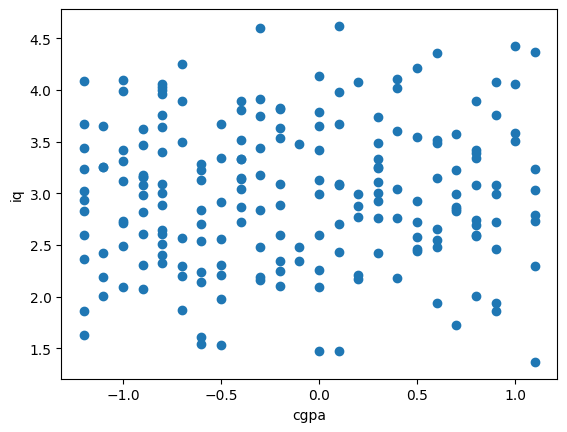

In [60]:
plt.scatter(new_data2['iq'],new_data2['package'])
plt.xlabel('cgpa')
plt.ylabel('iq')

In [61]:
x = new_data2.iloc[:,0:2]
y = new_data2.iloc[:,-1]

In [62]:
# splitting data
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [64]:
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [65]:
y_pred = lr.predict(x_test)

In [66]:
print('r2 score',r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

r2 score 0.7416511173054434


In [67]:
adjusted_r2_score = 1 - ((1-r2)*(60-1))/(60-1-1)

In [69]:
adjusted_r2_score

0.7371968262245028